# Set environment

In [1]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### keras
from keras            import Sequential, models, layers
from keras.utils      import to_categorical
from keras.optimizers import SGD, Adam

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### plot
import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"

/local_data/env-py3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
import tensorflow as tf
from keras import backend as k
### suppress warning
### ref: https://stackoverflow.com/questions/48608776/how-to-suppress-tensorflow-warning-displayed-in-result
tf.logging.set_verbosity(tf.logging.ERROR)

### restrict the memory usage of tensorflow
config = tf.ConfigProto()
config.gpu_options.allow_growth = True
k.tensorflow_backend.set_session(tf.Session(config=config))

In [3]:
### ref: https://machinelearningmastery.com/reproducible-results-neural-networks-keras/
from numpy.random import seed
#seed(SEED)
from tensorflow import set_random_seed
#set_random_seed(SEED)

# Load data

In [4]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

wrap01_data.P		wrap04_tsne_1e4_N10.P	    wrap05_img_1e4_var02.P
wrap02_scaled_k0.P	wrap04_tsne_1e4_N50.P	    wrap05_img_1e4_var05.P
wrap03_subs_1e4_N100.P	wrap05_img_1e4_N50_var01.P  wrap05_img_1e4_var10.P
wrap03_subs_1e4_N10.P	wrap05_img_1e4_N50_var10.P
wrap03_subs_1e4_N50.P	wrap05_img_1e4_var01.P


In [5]:
###
fname = "wrap05_img_1e4_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v01 = pickle.load(file)
file.close()

# Split to train and test data

In [6]:
dat_img = wrap_tsne_v01
dat_img_train, dat_img_test = train_test_split_datawrapper(
    dat_img, 8, 10)
print(dat_img_train)
print(dat_img_test)

Label: Counter({0: 80, 1: 80, 2: 80})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79]
    1: [ 80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115
 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133
 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151
 152 153 154 155 156 157 158 159]
    2: [160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 233 234 235 236 237 238 239]
------------------
Data Matrix: (2400000, 14

# get image

In [7]:
def set_label_onevsrest(label, target):
    label = label.copy()
    label[label != target] = 0
    label[label == target] = 1
    return label

In [8]:
target = 2 # SEB

In [9]:
img_train = dat_img_train.img
img_train = img_train.reshape((-1, 128, 128, 14))

y_train = dat_img_train.label.copy()
y_train = set_label_onevsrest(y_train, target)
print(y_train)
y_train = to_categorical(y_train)

print(img_train.shape)
print(y_train.shape)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
(240, 128, 128, 14)
(240, 2)


In [10]:
img_test = dat_img_test.img
img_test = img_test.reshape((-1, 128, 128, 14))

y_test = dat_img_test.label.copy()
y_test = set_label_onevsrest(y_test, target)
print(y_test)
y_test = to_categorical(y_test)

print(img_test.shape)
print(y_test.shape)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
(90, 128, 128, 14)
(90, 2)


# Build model

In [11]:
input_shape = (128, 128, 14)
n_class     = 2

### LENET

In [12]:
### set model
rate = 0.5
np.random.seed(SEED)
set_random_seed(SEED)
model = Sequential()

### conv layer
model.add(layers.Conv2D(filters=6, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(layers.AveragePooling2D())

### DROPOUT
model.add(layers.Dropout(rate))

model.add(layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(layers.AveragePooling2D())

### DROPOUT
model.add(layers.Dropout(rate))

### fully connected layer
model.add(layers.Flatten())
model.add(layers.Dense(units=120,     activation='relu'))
model.add(layers.Dense(units=84,      activation='relu'))
model.add(layers.Dense(units=n_class, activation='softmax'))

### compile the model
adam = Adam(lr=0.0001)
model.compile(
    optimizer=adam,
    loss='categorical_crossentropy',
    metrics=['accuracy'])

### name the model
model_lenet = model

In [13]:
model_lenet.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 126, 126, 6)       762       
_________________________________________________________________
average_pooling2d_1 (Average (None, 63, 63, 6)         0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 63, 63, 6)         0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 61, 61, 16)        880       
_________________________________________________________________
average_pooling2d_2 (Average (None, 30, 30, 16)        0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 30, 30, 16)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 14400)             0         
__________

In [14]:
%%time
### Train the model
history_lenet = model_lenet.fit(
    img_train, 
    y_train,
    epochs = 80,
    batch_size = 10,
    validation_data=(img_test, y_test))

Train on 240 samples, validate on 90 samples
Epoch 1/80
240/240 [==============================] - 2s 6ms/step - loss: 1.9468 - acc: 0.6250 - val_loss: 1.1295 - val_acc: 0.5889
Epoch 2/80
240/240 [==============================] - 1s 2ms/step - loss: 1.1371 - acc: 0.6375 - val_loss: 0.8895 - val_acc: 0.5333
Epoch 3/80
240/240 [==============================] - 1s 2ms/step - loss: 0.7813 - acc: 0.7125 - val_loss: 0.8662 - val_acc: 0.5111
Epoch 4/80
240/240 [==============================] - 1s 2ms/step - loss: 0.5073 - acc: 0.8000 - val_loss: 0.7390 - val_acc: 0.5556
Epoch 5/80
240/240 [==============================] - 1s 2ms/step - loss: 0.4396 - acc: 0.8417 - val_loss: 0.7380 - val_acc: 0.5667
Epoch 6/80
240/240 [==============================] - 1s 2ms/step - loss: 0.3485 - acc: 0.8458 - val_loss: 0.8973 - val_acc: 0.5000
Epoch 7/80
240/240 [==============================] - 1s 2ms/step - loss: 0.3047 - acc: 0.8792 - val_loss: 0.8182 - val_acc: 0.5333
Epoch 8/80
240/240 [===========

240/240 [==============================] - 1s 2ms/step - loss: 4.9209e-04 - acc: 1.0000 - val_loss: 1.2138 - val_acc: 0.6667
Epoch 63/80
240/240 [==============================] - 1s 2ms/step - loss: 9.9939e-04 - acc: 1.0000 - val_loss: 1.2532 - val_acc: 0.6667
Epoch 64/80
240/240 [==============================] - 1s 2ms/step - loss: 0.0012 - acc: 1.0000 - val_loss: 1.2862 - val_acc: 0.6556
Epoch 65/80
240/240 [==============================] - 1s 2ms/step - loss: 4.9298e-04 - acc: 1.0000 - val_loss: 1.3371 - val_acc: 0.6444
Epoch 66/80
240/240 [==============================] - 1s 2ms/step - loss: 8.0071e-04 - acc: 1.0000 - val_loss: 1.4103 - val_acc: 0.6444
Epoch 67/80
240/240 [==============================] - 1s 2ms/step - loss: 0.0012 - acc: 1.0000 - val_loss: 1.2195 - val_acc: 0.6556
Epoch 68/80
240/240 [==============================] - 1s 2ms/step - loss: 0.0153 - acc: 0.9958 - val_loss: 1.4616 - val_acc: 0.6444
Epoch 69/80
240/240 [==============================] - 1s 2ms/ste

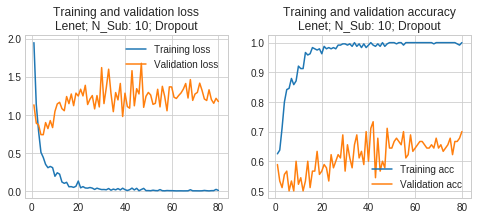

In [15]:
title   = "\nLenet; N_Sub: 10; Dropout"
history = history_lenet
### extract the training / validation loss from fitting history
acc      = history.history['acc']
val_acc  = history.history['val_acc']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

### visualize the training / validation loss
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
ax = axes[0]
ax.plot(epochs, loss,     '-', label='Training loss')
ax.plot(epochs, val_loss, '-',  label='Validation loss')
ax.set_title('Training and validation loss' + title)
ax.legend()

ax = axes[1]
ax.plot(epochs, acc,      '-', label='Training acc')
ax.plot(epochs, val_acc,  '-',  label='Validation acc')
ax.set_title('Training and validation accuracy' + title)
ax.legend()

plt.show()

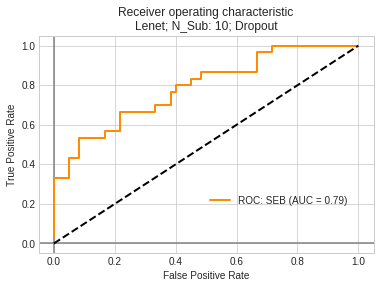

In [16]:
y_prob = model_lenet.predict_proba(img_test)

### calculate fpr and tpr
i = 1
fpr, tpr, roc_auc = dict(), dict(), dict()
fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
roc_auc[i] = auc(fpr[i], tpr[i])

### Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

#######################################################
### set plot
plt.figure()
lw = 2

### since there is only two classes, below are the same
plt.plot(fpr[1], tpr[1], color='darkorange', lw=lw, label='ROC: SEB (AUC = %0.2f)' % roc_auc[1])

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic' + title)
plt.legend(loc=(0.5, 0.2)) #plt.legend(loc="lower right")

plt.show()

### VGG16

In [15]:
### set model
np.random.seed(SEED)
model = Sequential()

model.add(layers.Conv2D(64, (3, 3), input_shape=input_shape, padding='same', activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

### DROPOUT
model.add(layers.Dropout(rate))

model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

### DROPOUT
model.add(layers.Dropout(rate))

model.add(layers.Flatten())
model.add(layers.Dense(4096,    activation='relu'))
model.add(layers.Dense(4096,    activation='relu'))
model.add(layers.Dense(n_class, activation='softmax'))

### compile the model
adam = Adam(lr=0.0001)
model.compile(
    optimizer=adam,
    loss='categorical_crossentropy',
    metrics=['accuracy'])

### name the model
model_vgg16 = model

In [16]:
#model_vgg16.summary()
model_vgg16.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 128, 128, 64)      8128      
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 128, 128, 64)      36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 64, 64, 128)       73856     
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 64, 64, 128)       147584    
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 32, 32, 128)       0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 32, 32, 256)       295168    
__________

In [17]:
%%time
### Train the model
history = model_vgg16.fit(
    img_train, 
    y_train,
    epochs = 20,
    batch_size = 10,
    validation_data=(img_test, y_test))

Train on 240 samples, validate on 90 samples
Epoch 1/20
240/240 [==============================] - 6s 24ms/step - loss: 0.7265 - acc: 0.5458 - val_loss: 0.6681 - val_acc: 0.6667
Epoch 2/20
240/240 [==============================] - 2s 9ms/step - loss: 0.6488 - acc: 0.6667 - val_loss: 0.6406 - val_acc: 0.6667
Epoch 3/20
240/240 [==============================] - 2s 9ms/step - loss: 0.6118 - acc: 0.6667 - val_loss: 0.5830 - val_acc: 0.6667
Epoch 4/20
240/240 [==============================] - 2s 9ms/step - loss: 0.5729 - acc: 0.6667 - val_loss: 0.4563 - val_acc: 0.6667
Epoch 5/20
240/240 [==============================] - 2s 9ms/step - loss: 0.4604 - acc: 0.6667 - val_loss: 0.6849 - val_acc: 0.6667
Epoch 6/20
240/240 [==============================] - 2s 9ms/step - loss: 0.6666 - acc: 0.6667 - val_loss: 0.6756 - val_acc: 0.6667
Epoch 7/20
240/240 [==============================] - 2s 9ms/step - loss: 0.6752 - acc: 0.6667 - val_loss: 0.6793 - val_acc: 0.6667
Epoch 8/20
240/240 [==========

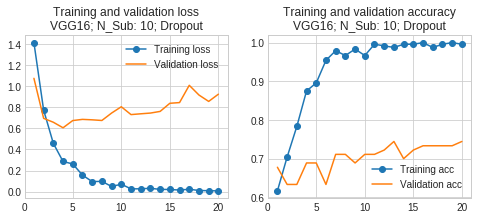

In [22]:
title   = "\nVGG16; N_Sub: 10; Dropout"

### extract the training / validation loss from fitting history
acc      = history.history['acc']
val_acc  = history.history['val_acc']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

### visualize the training / validation loss
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
ax = axes[0]
ax.plot(epochs, loss,     'o-', label='Training loss')
ax.plot(epochs, val_loss, '-',  label='Validation loss')
ax.set_title('Training and validation loss' + title)
ax.legend()

ax = axes[1]
ax.plot(epochs, acc,      'o-', label='Training acc')
ax.plot(epochs, val_acc,  '-',  label='Validation acc')
ax.set_title('Training and validation accuracy' + title)
ax.legend()

plt.show()

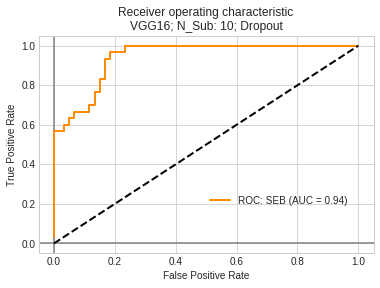

In [23]:
y_prob = model_vgg16.predict_proba(img_test)

### calculate fpr and tpr
i = 1
fpr, tpr, roc_auc = dict(), dict(), dict()
fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
roc_auc[i] = auc(fpr[i], tpr[i])

### Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

#######################################################
### set plot
plt.figure()
lw = 2

### since there is only two classes, below are the same
plt.plot(fpr[1], tpr[1], color='darkorange', lw=lw, label='ROC: SEB (AUC = %0.2f)' % roc_auc[1])

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic' + title)
plt.legend(loc=(0.5, 0.2)) #plt.legend(loc="lower right")

plt.show()